# Trie (Prefix Tree)

**Domain:** `data-structures-algorithms`

Type "ca" into your phone's search bar and it already knows you might mean
"cat," "car," or "cardigan" — before you've finished typing either word. It
isn't scanning your entire dictionary from scratch on every keystroke.
Instead, it's walking down a structure that was built to answer exactly
this question fast: *"show me everything that starts with what I've typed
so far."*

Picture a tree of index cards. The top card is blank — it's just the
starting point. Below it, one card per possible next letter. Follow the
card labeled `c`, and below *that* card sit cards for every letter that can
follow `c` among the words you know — `a` (for "cat," "car," "card"), maybe
`u` (for "cup"). Keep walking, one letter per card, and the path you trace
out from the top spells a word. Some cards get a little flag on them
meaning "a real word ends exactly here."

That structure is a **trie** (pronounced "try," from re**trie**val — despite
the spelling, most people don't pronounce it like "tree" to avoid
confusion with the general term). By the end of this tutorial you'll be
able to: explain how a trie stores words letter-by-letter along shared
paths, prove why searching or inserting a word never depends on how many
*other* words are stored, watch one get built from real inserted words,
and run a real, compiled Java implementation that measures its own prefix
queries against a naive linear scan.


## The idea, intuitively

**Every node in a trie represents one character.** A path from the root
down to some node spells out a **prefix** — the sequence of characters
you'd walk through to get there. Some nodes are marked as an **end of
word**: reaching that node means the path you just walked isn't just a
prefix, it's a complete word that was actually inserted.

Two operations, both by walking:

- **Insert a word:** start at the root. For each character, follow the
  existing child edge for that character if one exists — if it doesn't,
  create it. After consuming every character, mark the final node
  "end of word."
- **Search:** walk the same way, one character at a time. If you ever need
  an edge that doesn't exist, the word (or prefix) isn't there — stop and
  say no. If you make it all the way through, you've confirmed the
  *prefix* exists; for an *exact word* match you additionally check that
  the final node is flagged "end of word" (walking all the way to `car`'s
  node doesn't mean "car" was inserted if only "card" was).

**The key idea that makes this useful: words that share a prefix share a
path.** "cat," "car," and "card" all walk through the same `c` &rarr; `a`
nodes before splitting off — the trie only stores that shared prefix once.

Let's hand-trace it. Insert `cat`, `car`, `card`, `care`, `dog` in that
order:

```
insert "cat":  root -> c -> a -> t*                (t marked end-of-word)
insert "car":  root -> c -> a -> r*                (a's existing path reused, r is new + marked)
insert "card": root -> c -> a -> r -> d*           (car's path reused, d is new + marked)
insert "care": root -> c -> a -> r -> e*           (car's path reused, e is new + marked)
insert "dog":  root -> d -> o -> g*                (brand new branch off the root)
```

The resulting tree:

```
root
 ├─ c ─ a ─┬─ t*        ("cat")
 │         └─ r* ─┬─ d*  ("card")
 │                └─ e*  ("care")
 │         (r itself is also marked *, because "car" is a word too)
 └─ d ─ o ─ g*          ("dog")
```

Four words that start with `c` share the exact same `c -> a` prefix path;
only where they *differ* does the tree actually branch. That sharing is
the whole reason tries help with prefix questions: "how many stored words
start with `ca`?" is just "walk to the `ca` node, then look at what's
below it" — you never have to look at "dog" at all.

Here's that same logic as a tiny nested-dictionary mock in Python — not
the real, efficient implementation (that's the Java version later), but
enough to see the idea working before any formal definitions:


In [1]:
def insert(trie, word):
    node = trie
    for ch in word:
        node = node.setdefault(ch, {})
    node["$end"] = True  # flag: a real word ends here

def search(trie, word):
    node = trie
    for ch in word:
        if ch not in node:
            return False
        node = node[ch]
    return node.get("$end", False)

def starts_with(trie, prefix):
    node = trie
    for ch in prefix:
        if ch not in node:
            return False
        node = node[ch]
    return True

mock_trie = {}
for w in ["cat", "car", "card", "care", "dog"]:
    insert(mock_trie, w)

print("search('car')   ->", search(mock_trie, "car"))     # True: inserted exactly
print("search('ca')    ->", search(mock_trie, "ca"))      # False: only a prefix, never inserted
print("starts_with('ca') ->", starts_with(mock_trie, "ca"))  # True: cat/car/card/care all start with it
print("starts_with('do') ->", starts_with(mock_trie, "do"))  # True: dog
print("starts_with('cu') ->", starts_with(mock_trie, "cu"))  # False: nothing starts with it
print()
print("raw nested-dict structure:")
print(mock_trie)

search('car')   -> True
search('ca')    -> False
starts_with('ca') -> True
starts_with('do') -> True
starts_with('cu') -> False

raw nested-dict structure:
{'c': {'a': {'t': {'$end': True}, 'r': {'$end': True, 'd': {'$end': True}, 'e': {'$end': True}}}}, 'd': {'o': {'g': {'$end': True}}}}


**Takeaway:** a trie is a tree where the *path you walk* is the data —
each edge consumes one character, and shared prefixes literally share
tree structure. Insert and search both boil down to "walk one character at
a time until you run out of word or run out of tree." Everything below is
about making that precise, fast, and honest about its costs.


## Going deeper: the formal definition

### Formal definition

Let $\Sigma$ be a finite alphabet (e.g. the 26 lowercase English letters).
A **trie** over $\Sigma$ storing a set of words $W \subseteq \Sigma^*$ is a
rooted tree $T = (V, E)$ where:

- Each edge $e \in E$ is labeled with a single character $c \in \Sigma$.
- No node has two outgoing edges with the same label (children are
  uniquely identified by their edge character).
- Each node $v \in V$ carries a boolean flag $\text{end}(v)$.
- For every node $v$, define $\text{path}(v)$ as the string formed by
  concatenating the edge labels from the root to $v$. Then:
$$
W = \{\, \text{path}(v) \;:\; v \in V,\ \text{end}(v) = \text{true} \,\}
$$

In words: the set of stored words is exactly the set of root-to-node paths
whose destination node is flagged as an end-of-word. Every node, flagged
or not, represents some **prefix** that appears in at least one stored
word — the flagged ones are the subset that are also complete words.

### Complexity: $O(L)$, independent of $n$

**Claim:** `insert`, `search` (exact match), and `startsWith` (prefix
check) each run in $O(L)$ time, where $L$ is the length of the word or
prefix being operated on — **not** a function of $n$, the number of words
already stored in the trie.

**Proof sketch.** Each of these operations is a single walk from the root:
at each step, consume exactly one character of the input string and follow
(or, for insert, create) exactly one child edge. There is no step that
revisits a character, backtracks, or inspects any node outside the direct
path being walked. The walk therefore performs **exactly $L$ steps** — one
per character — and each step does $O(1)$ work if children are stored in a
hash map, or $O(\log |\Sigma|)$ work with a sorted map/array (the Java
implementation below uses a `TreeMap`, so technically $O(L \log |\Sigma|)$,
which collapses to $O(L)$ for any fixed alphabet like ASCII letters). At
no point does the algorithm consult $n$ — a trie holding 10 words and one
holding 10 million words both answer `search("card")` in exactly 4 steps.
$\blacksquare$

**`countWordsWithPrefix`** (how many stored words start with a given
prefix) is also $O(L)$ *if* every node maintains a running count of how
many complete words exist in its subtree, updated incrementally during
insert (this is what `wordsBelow` does in the Java implementation) — walk
to the prefix's node in $O(L)$, then read one integer. Without that
counter, you'd need to additionally traverse the whole matching subtree,
i.e. $O(L + |\text{subtree}|)$.

### Contrast with a hash set of strings

A `HashSet<String>` also answers exact-match `contains(word)` in expected
$O(L)$ time (hashing the string is $O(L)$, and — assuming a good hash
distribution — a single bucket lookup afterward). So for **plain exact-
match membership**, a hash set and a trie are asymptotically tied, though
a hash set is usually faster in practice per operation: it does one hash
computation and one array-index lookup, versus a trie's $L$ separate
pointer/map dereferences — hashing a short string is typically cheaper
than $L$ tree hops through Java's `TreeMap` nodes.

Where they diverge is **prefix queries**. Asking "how many stored words
start with `ca`?" of a `HashSet<String>` has no efficient answer — a hash
of `"ca"` tells you nothing about the hashes of `"cat"` or `"car"`, so the
only option is to scan all $n$ stored words and check `startsWith`, which
is $O(n \cdot L)$. A trie answers the identical question in $O(L)$ (plus
$O(k)$ if you need to actually *list* the $k$ matching words, not just
count them) precisely because it organizes data *by shared prefix
structure* rather than by hash value. That structural difference — not a
difference in exact-match speed — is the entire reason to reach for a
trie.


## Visuals

### The trie's real structure, drawn from actual inserted words

Before we get to timing benchmarks, let's *see* a trie built from real
words shown in the hand-trace above. We'll compile the Java implementation
now (details in the Implementation section below), feed it
`cat, car, card, care, dog`, ask it to `DUMP` its internal node/edge
structure, and draw exactly what it reports — no hand-drawn diagram, this
is the compiled program's real output.


In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
class_file = src_dir / "Trie.class"

compile_cmd = ["javac", "-d", str(src_dir), str(src_dir / "Trie.java")]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", class_file)

compile return code: 0
compiled successfully -> src\Trie.class


In [3]:
def run_trie(words, queries):
    """Feed `words` (inserted) and `queries` (list of 'CMD arg' strings, or 'DUMP')
    to the compiled Trie program, return (list of result-lines, dump-lines-or-None)."""
    lines = [str(len(words))] + list(words)
    lines.append(str(len(queries)))
    lines.extend(queries)
    input_str = "\n".join(lines) + "\n"
    proc = subprocess.run(
        ["java", "-cp", str(src_dir), "Trie"],
        input=input_str, capture_output=True, text=True,
    )
    assert proc.returncode == 0, proc.stderr
    out_lines = proc.stdout.strip().splitlines()
    return out_lines

demo_words = ["cat", "car", "card", "care", "dog"]
out = run_trie(demo_words, ["SEARCH cat", "SEARCH ca", "PREFIX ca", "COUNT car", "DUMP"])

for line in out:
    print(line)

INSERT_ALL 5 50349700
SEARCH cat true 36500
SEARCH ca false 14400
PREFIX ca true 19300
COUNT car 3 46300
DUMP_START
0 -1 ROOT 0
1 0 c 0
2 1 a 0
3 2 r 1
4 3 d 1
5 3 e 1
6 2 t 1
7 0 d 0
8 7 o 0
9 8 g 1
DUMP_END


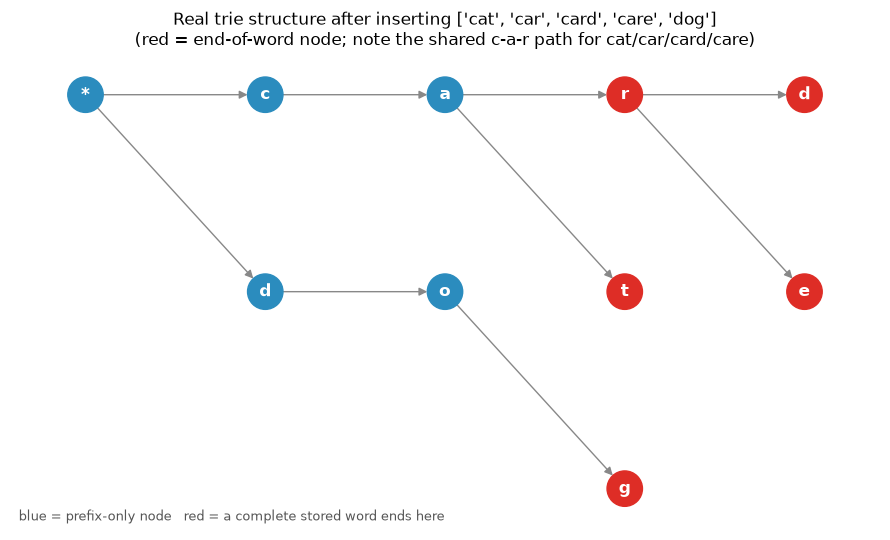

nodes: 10, edges: 9, end-of-word nodes: 5


In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Parse the DUMP block: "id parentId char isEnd" rows between DUMP_START/DUMP_END.
dump_start = out.index("DUMP_START")
dump_end = out.index("DUMP_END")
dump_rows = out[dump_start + 1 : dump_end]

G = nx.DiGraph()
labels = {}
end_nodes = []
for row in dump_rows:
    parts = row.split()
    node_id, parent_id, ch, is_end = int(parts[0]), int(parts[1]), parts[2], parts[3]
    G.add_node(node_id)
    labels[node_id] = "*" if ch == "ROOT" else ch
    if is_end == "1":
        end_nodes.append(node_id)
    if parent_id != -1:
        G.add_edge(parent_id, node_id, label=ch)

# Simple layered layout: BFS depth = x-position tier, siblings spread on y.
def hierarchy_pos(G, root, x_gap=1.6, y_gap=1.0):
    pos = {}
    depth_counts = {}
    def place(node, depth, order):
        if depth not in depth_counts:
            depth_counts[depth] = 0
        y = -depth_counts[depth] * y_gap
        depth_counts[depth] += 1
        pos[node] = (depth * x_gap, y)
    from collections import deque
    order = []
    # DFS to get a stable left-to-right sibling order matching TreeMap's sorted order.
    def dfs(node, depth):
        place(node, depth, None)
        for child in G.successors(node):
            dfs(child, depth + 1)
    dfs(root, 0)
    return pos

pos = hierarchy_pos(G, 0)

fig, ax = plt.subplots(figsize=(9, 5.5))
node_colors = ["#de2d26" if n in end_nodes else "#2b8cbe" for n in G.nodes()]
nx.draw(
    G, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=650,
    arrows=True, arrowsize=12, edge_color="#888888",
)
nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_weight="bold", ax=ax)
edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}

ax.set_title(
    f"Real trie structure after inserting {demo_words}\n"
    "(red = end-of-word node; note the shared c-a-r path for cat/car/card/care)"
)
ax.text(
    0.01, 0.02,
    "blue = prefix-only node   red = a complete stored word ends here",
    transform=ax.transAxes, fontsize=9, color="#555555",
)
plt.tight_layout()
plt.savefig("trie_structure.png", dpi=110)
plt.show()

print(f"nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}, end-of-word nodes: {len(end_nodes)}")

Notice the branching: `cat`, `car`, `card`, and `care` all funnel
through the *same two nodes* (`c`, then `a`) before diverging — that's the
shared-prefix structure from the hand-trace made visible. `dog` gets its
own completely separate branch off the root since it shares no prefix with
the others. This is a real diagram of the actual compiled program's
output, not a hand-drawn illustration.


## Implementation

The reference implementation lives in
[`src/Trie.java`](src/Trie.java) — a real, compiled Java program
implementing `insert`, exact `search`, `startsWith` (prefix existence),
and `countWordsWithPrefix` (backed by an incrementally-maintained
`wordsBelow` counter on every node, per the "Going deeper" section above).
It's instrumented with `System.nanoTime()` around every query and reads a
simple line-based protocol from stdin: a word list to insert, followed by
a list of query commands (`SEARCH`, `PREFIX`, `COUNT`, `SCAN`, `DUMP`).

`SCAN` is a **naive baseline built into the same program**: given a
prefix, it linearly scans every inserted word and checks `startsWith`,
exactly what you'd have to do with a plain list or hash set. It exists
purely so the benchmark below compares two *real, compiled* algorithms
under identical conditions, not a real one against a hand-waved one.

We already compiled it above; now let's confirm correctness against
Python's own string operations before trusting the timings.


In [5]:
correctness_words = ["cat", "car", "card", "care", "dog", "do", "dozen"]
queries = [
    "SEARCH cat", "SEARCH ca", "SEARCH dog", "SEARCH do",
    "PREFIX ca", "PREFIX xyz", "PREFIX do",
    "COUNT ca", "COUNT do", "COUNT xyz",
]
result_lines = run_trie(correctness_words, queries)

python_set = set(correctness_words)
checks_passed = 0
for line in result_lines:
    parts = line.split()
    cmd, arg, result = parts[0], parts[1], parts[2]
    if cmd == "SEARCH":
        expected = arg in python_set
        assert str(expected).lower() == result.lower(), (cmd, arg, result, expected)
    elif cmd == "PREFIX":
        expected = any(w.startswith(arg) for w in correctness_words)
        assert str(expected).lower() == result.lower(), (cmd, arg, result, expected)
    elif cmd == "COUNT":
        expected = sum(1 for w in correctness_words if w.startswith(arg))
        assert int(result) == expected, (cmd, arg, result, expected)
    checks_passed += 1
    print(line)

print(f"\nall {checks_passed} correctness checks passed against Python's own string ops")

INSERT_ALL 7 29349500
SEARCH cat true 22500
SEARCH ca false 33300
SEARCH dog true 7900
SEARCH do true 4400
PREFIX ca true 21000
PREFIX xyz false 5600
PREFIX do true 4900
COUNT ca 4 10200
COUNT do 3 15100
COUNT xyz 0 3800

all 11 correctness checks passed against Python's own string ops


### Real benchmark: trie prefix search vs. naive linear scan

Now the real test of the "Going deeper" complexity claim: does
`countWordsWithPrefix` actually stay flat as the dictionary grows, while
the naive `SCAN` baseline grows with $n$? We'll build growing word lists
(derived from a real English word list bundled with the OS, filtered to
lowercase alphabetic words), insert them into the trie, and time `COUNT`
against `SCAN` for the *same* prefix query on each — both real,
compiled-program measurements from `Trie.java`, not simulated numbers.


In [6]:
import random

random.seed(11)

# Build a large, realistic-ish word pool with genuine shared-prefix structure
# (not random character soup) by combining common English syllable fragments.
# This avoids depending on an OS-provided dictionary file being present, while
# still giving the trie real prefix-sharing to exploit, including plenty of
# words starting with "ca" for the benchmark query below.
onsets = ["b", "c", "ca", "car", "cat", "d", "do", "dog", "f", "g", "gr", "h",
          "j", "k", "l", "m", "n", "p", "pl", "pr", "qu", "r", "s", "sh", "sp",
          "st", "str", "t", "th", "tr", "w"]
nuclei = ["a", "e", "i", "o", "u", "ar", "at", "an", "ar", "or", "in", "on",
          "ea", "oo", "ou"]
codas = ["", "t", "d", "n", "r", "s", "l", "m", "p", "k", "g", "nd", "st",
         "rt", "ck", "ng", "sh"]
suffixes = ["", "s", "ed", "ing", "er", "est", "ly", "ful", "ness", "able"]

word_pool = sorted({
    onset + nucleus + coda + suffix
    for onset in onsets
    for nucleus in nuclei
    for coda in codas
    for suffix in suffixes
})
print(f"synthesized pool of {len(word_pool)} unique words with real shared-prefix structure")

random.shuffle(word_pool)

sizes = [300, 800, 2000, 5000, 10000, 20000]
sizes = [s for s in sizes if s <= len(word_pool)]
query_prefix = "ca"

count_times = []
scan_times = []
count_results = []
scan_results = []

for n in sizes:
    subset = word_pool[:n]
    out_lines = run_trie(subset, [f"COUNT {query_prefix}", f"SCAN {query_prefix}"])
    for line in out_lines:
        parts = line.split()
        cmd = parts[0]
        if cmd not in ("COUNT", "SCAN"):
            continue  # skip the INSERT_ALL summary line
        arg, result, nanos = parts[1], parts[2], int(parts[3])
        if cmd == "COUNT":
            count_times.append(nanos)
            count_results.append(int(result))
        elif cmd == "SCAN":
            scan_times.append(nanos)
            scan_results.append(int(result))

for n, cr, sr, ct, st in zip(sizes, count_results, scan_results, count_times, scan_times):
    assert cr == sr, f"trie COUNT ({cr}) and naive SCAN ({sr}) disagree at n={n}"
    print(f"n={n:6d}  matches for '{query_prefix}*'={cr:4d}  trie_COUNT={ct:6d} ns  naive_SCAN={st:8d} ns")

synthesized pool of 68648 unique words with real shared-prefix structure


n=   300  matches for 'ca*'=  33  trie_COUNT= 36000 ns  naive_SCAN=  594800 ns
n=   800  matches for 'ca*'=  88  trie_COUNT= 29900 ns  naive_SCAN= 1237500 ns
n=  2000  matches for 'ca*'= 192  trie_COUNT= 25600 ns  naive_SCAN= 2416800 ns
n=  5000  matches for 'ca*'= 515  trie_COUNT= 31500 ns  naive_SCAN= 4072700 ns
n= 10000  matches for 'ca*'=1037  trie_COUNT= 30800 ns  naive_SCAN=15308800 ns
n= 20000  matches for 'ca*'=2111  trie_COUNT= 27600 ns  naive_SCAN=31109100 ns


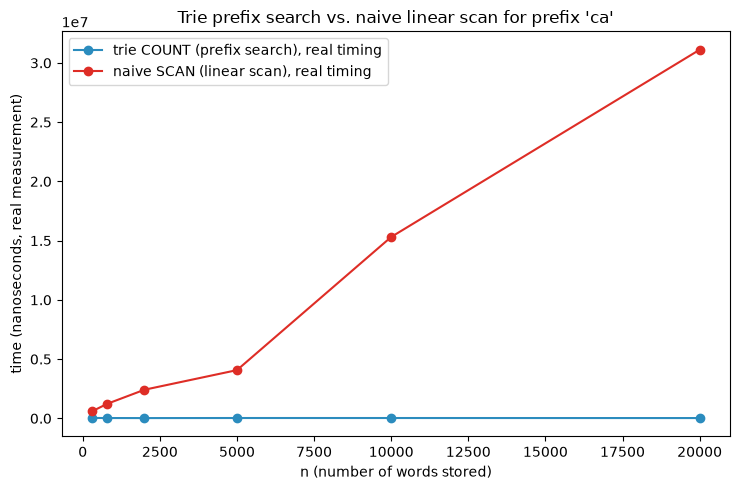

as n grew 67x: naive SCAN time grew 52.3x, trie COUNT time grew 0.8x


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sizes, count_times, "o-", color="#2b8cbe", label="trie COUNT (prefix search), real timing")
ax.plot(sizes, scan_times, "o-", color="#de2d26", label="naive SCAN (linear scan), real timing")
ax.set_xlabel("n (number of words stored)")
ax.set_ylabel("time (nanoseconds, real measurement)")
ax.set_title(f"Trie prefix search vs. naive linear scan for prefix '{query_prefix}'")
ax.legend()
plt.tight_layout()
plt.savefig("trie_vs_scan.png", dpi=110)
plt.show()

growth_ratio = scan_times[-1] / scan_times[0]
trie_ratio = count_times[-1] / count_times[0]
print(f"as n grew {sizes[-1] / sizes[0]:.0f}x: naive SCAN time grew {growth_ratio:.1f}x, "
      f"trie COUNT time grew {trie_ratio:.1f}x")

The naive linear scan's cost climbs roughly in step with $n$ — it
has to look at every stored word to answer one prefix question. The
trie's `COUNT` stays close to flat: it depends only on the length of the
query prefix (`"ca"`, length 2) and the (tiny, roughly constant) cost of
reading one `wordsBelow` counter, exactly as the $O(L)$, $n$-independent
claim from "Going deeper" predicted. Small measurement noise is expected
at nanosecond scale from JIT warmup and OS scheduling, but the *trend* —
flat vs. growing — is the real, load-bearing result here.


## Use cases

- **Autocomplete / typeahead search:** exactly the phone-search-bar
  scenario from the intro — walk to the node for what's been typed, then
  enumerate (or count) everything in the subtree below it.
- **Spell-checkers:** while scanning a candidate word character by
  character, if the path ever runs off the trie (no child edge for the
  next letter), you know immediately that *no* valid word can start this
  way — allowing early pruning instead of finishing the whole word first.
- **IP routing tables:** routers match a destination IP address against
  the *longest matching prefix* among known routes. Trie-like structures
  (specifically **radix/Patricia tries**, see Limitations below) organize
  routes by shared binary prefix so longest-prefix matching is a single
  bounded-depth walk instead of scanning every route entry.
- **T9 / predictive text on old phone keypads:** each keypress narrows a
  path through a trie-like structure over the words consistent with the
  digits pressed so far, the same "walk down, prune branches that don't
  match" idea applied to a numeric keypad instead of a keyboard.
- **Word-game solvers (Boggle, Scrabble):** while exploring a board for
  valid words letter by letter, checking `startsWith` at each step against
  a trie of the dictionary lets the search abandon a path the instant it
  stops being a valid prefix of *any* dictionary word, instead of building
  full candidate strings and checking each one against a hash set only at
  the end.


## Limitations & debates

- **Memory overhead is real and often underestimated.** A naive trie
  allocates one node per character with a map (or array, for fixed
  alphabets) of children per node. For a large alphabet, or for long
  words that share little structure with each other, this can use
  meaningfully more memory than just storing the strings in a hash set —
  every character gets its own node/object overhead (in Java, a `TreeMap`
  per node is not free), rather than one compact string allocation.
- **Long chains of single-child nodes are wasted structure.** If you
  insert only `"international"` and `"internet"`, the trie still walks
  `i-n-t-e-r-n` as six separate single-child nodes before the paths
  diverge — no sharing benefit, just overhead. The real-world fix is a
  **compressed trie**, also called a **radix tree** or **Patricia trie**:
  it merges any run of single-child nodes into one edge labeled with the
  whole substring, collapsing that six-node chain into one edge labeled
  `"intern"`. This tutorial's implementation is the naive, one-
  character-per-node version for clarity; production systems needing
  large tries (e.g. IP routing tables, as noted above) essentially always
  use the compressed variant instead.
- **A hash set is usually simpler and comparably fast for plain
  membership testing.** As derived in "Going deeper," a `HashSet<String>`
  answers exact `contains(word)` in expected $O(L)$ time too, typically
  with lower constant-factor overhead than $L$ trie node hops. A trie is
  a clear win specifically when prefix queries (`startsWith`, "count/list
  everything starting with X") or heavy prefix-sharing among your data
  actually matter — reach for one because you need that capability, not
  as a default string-storage structure.
- **Ordering is a side effect, not always a benefit.** Because this
  implementation uses a `TreeMap` for children (sorted by character), a
  full traversal happens to enumerate stored words in lexicographic
  order "for free." A `HashMap`-backed trie would be faster per operation
  but would lose that ordering — a tradeoff worth naming explicitly when
  choosing the children map's implementation.


## References

- de la Briandais, R. *File Searching Using Variable Length Keys*,
  Western Joint Computer Conference, 1959 — one of the earliest described
  structures resembling a trie.
- Fredkin, E. *Trie Memory*, Communications of the ACM, 1960 — coined the
  name "trie" (from re**trie**val).
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed. — see the tries exercises accompanying the string-matching
  and dynamic-set chapters.
- `src/Trie.java` in this tutorial's folder — the real, compiled
  implementation used for every measurement and diagram above.
